In [1]:
import matplotlib.pyplot as plt
plt.style.use("dark_background")
import numpy as np

## Task 1: Solving Laplace's Equation

### 1. Analysis
Laplace's equation in 2D is:
$$ \frac{\partial^2 V}{\partial x^2} + \frac{\partial^2 V}{\partial y^2} = 0 $$

Using the central finite-difference approximation for the second derivatives with grid spacing $h$:
$$ \frac{\partial^2 V}{\partial x^2} \approx \frac{V_{i-1,j} - 2V_{i,j} + V_{i+1,j}}{h^2} $$
$$ \frac{\partial^2 V}{\partial y^2} \approx \frac{V_{i,j-1} - 2V_{i,j} + V_{i,j+1}}{h^2} $$

Substituting into Laplace's equation:
$$ \frac{V_{i-1,j} - 2V_{i,j} + V_{i+1,j}}{h^2} + \frac{V_{i,j-1} - 2V_{i,j} + V_{i,j+1}}{h^2} = 0 $$

Multiply both sides by $h^2$:
$$ V_{i-1,j} - 2V_{i,j} + V_{i+1,j} + V_{i,j-1} - 2V_{i,j} + V_{i,j+1} = 0 $$

Rearranging for $V_{i,j}$:
$$ 4V_{i,j} = V_{i-1,j} + V_{i+1,j} + V_{i,j-1} + V_{i,j+1} $$
$$ \boxed{V_{i,j} = \frac{1}{4} \left( V_{i-1,j} + V_{i+1,j} + V_{i,j-1} + V_{i,j+1} \right)} $$

This is the finite-difference equation for the potential at grid point $(i, j)$: the potential equals the average of its four nearest neighbours.

### 2. Jacobi Method

In [2]:
N = 101          # nos of grid points 
tol = 10**-6  # tolerance
max_iter = 100000

V = np.zeros((N, N)) # Our Domain

# The dirichlet boundary conditions
V[-1, :] = 1.0   # bottom row
V[:, -1] = 1.0   # right column

V_new = V.copy()

for k in range(max_iter):
    # Jacobi vectorized update for interior points
    V_new[1:-1, 1:-1] = (1/4) * (V[0:-2, 1:-1] + V[2:, 1:-1] +
                                   V[1:-1, 0:-2] + V[1:-1, 2:])

    diff = np.max(np.abs(V_new - V))
    V[:] = V_new[:]
    if diff < tol:
        print(f"Jacobi method converged in {k+1} iterations")
        break



for k in range(max_iter):
    max_diff = 0.0
    
    for i in range(1, N - 1):
        for j in range(1, N - 1):
            old_val = V[i, j]

            # Gauss-Seidel: update V in-place so neighbours use latest values
            V[i, j] = (1/4) * (V[i-1, j] + V[i+1, j] +
                               V[i, j-1] + V[i, j+1])

            diff = abs(V[i, j] - old_val)
            if diff > max_diff:
                max_diff = diff
    if max_diff <= tol:
        print(f"Gauss-Seidel method converged in {k+1} iterations")
        break


V_jacobi = V.copy()


Jacobi method converged in 12140 iterations
Gauss-Seidel method converged in 703 iterations


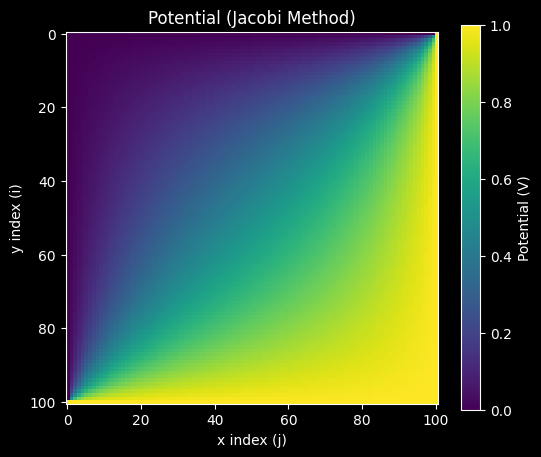

In [3]:
# 3. 

plt.figure(figsize=(6, 5))
plt.imshow(V_jacobi, interpolation='none') # Heat map is here
plt.colorbar(label='Potential (V)')
plt.title('Potential (Jacobi Method)')
plt.xlabel('x index (j)')
plt.ylabel('y index (i)')
plt.show()

In [4]:
# 4. 

V_gs = np.zeros((N, N)) # Same Domain As beofre, just a new copy


V_gs[-1, :] = 1.0  # bottom wall
V_gs[:, -1] = 1.0  # right wall

for k in range(max_iter):
    max_diff = 0.0
    
    for i in range(1, N - 1):
        for j in range(1, N - 1):
            old_val = V_gs[i, j]

            # This is the new Method update
            V_gs[i, j] = (1/4) * (V_gs[i-1, j] + V_gs[i+1, j] +
                                  V_gs[i, j-1] + V_gs[i, j+1])
            diff = abs(V_gs[i, j] - old_val)
            if diff > max_diff:
                max_diff = diff
    if max_diff <= tol:
        print(f"Gauss-Seidel method converged in {k+1} iterations")
        break



Gauss-Seidel method converged in 6798 iterations


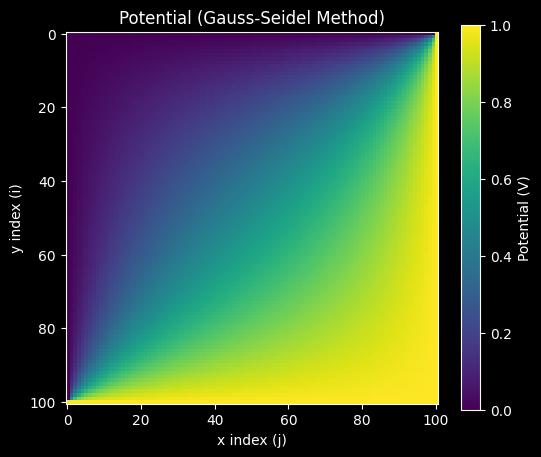

In [5]:
plt.figure(figsize=(6, 5))
plt.imshow(V_gs, interpolation='none')
plt.colorbar(label='Potential (V)')
plt.title('Potential (Gauss-Seidel Method)')
plt.xlabel('x index (j)')
plt.ylabel('y index (i)')
plt.show()

In [6]:
#5. 

# Grounded box (all boundaries = 0 V)
V_cap = np.zeros((N, N))
V_new_cap = np.zeros((N, N))


plate_x_start = 0
plate_x_end   = 2+6+2 # cm
plate1_y = 10   # +1 V plate on  the left on the image
plate2_y = 6   # -1 V plate on the right on the image




for k in range(max_iter): # Using jacobi 
    V_new_cap[1:-1, 1:-1] = (1/4) * (V_cap[0:-2, 1:-1] + V_cap[2:, 1:-1] +
                                      V_cap[1:-1, 0:-2] + V_cap[1:-1, 2:])
    
    # Internal Potential set
    V_new_cap[plate1_y, plate_x_start:plate_x_end+1] =  1.0
    V_new_cap[plate2_y, plate_x_start:plate_x_end+1] = -1.0

    diff = np.max(np.abs(V_new_cap - V_cap))
    V_cap[:] = V_new_cap[:]
    if diff <= tol:
        print(f"{k+1} iterations")
        break


5779 iterations


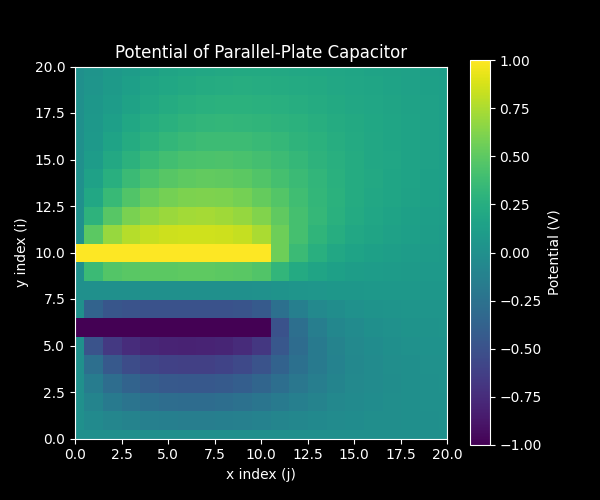

In [19]:
# 6. 
plt.figure(figsize=(6, 5))
plt.imshow(V_cap, interpolation='none')
plt.xlim(0,20)
plt.ylim(0,20)
plt.title('Potential of Parallel-Plate Capacitor')
plt.xlabel('x index (j)')
plt.ylabel('y index (i)')

plt.colorbar(label='Potential (V)')
plt.show()

### 7. Analysis
For *infinite* parallel-plate capacitor,the E field is uniform between plates, 
so  parallel lines to the plates. Outside the plates the field is zero.

I am not sure why I see a horizontal line instead of a vertical lines.


## Task 2: 

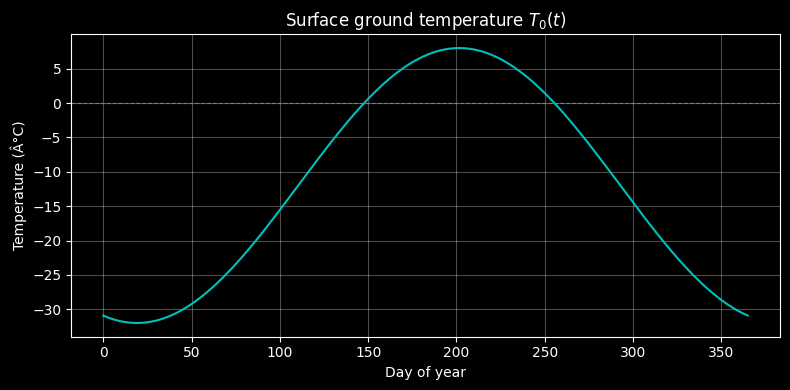

In [8]:
# 1.


tau = 365.0 # days
A   = -12.0  # average temperature (C)
B   = 20.0  # amplitude (Celcius)
phi = -1.9  # rad
alpha = 0.1   # 
L = 40.0  # meters
mT = 30.0 / 1000 # C/m

t = np.arange(0, 366)
T0 = A + B * np.sin((2 * np.pi * t / tau) + phi)

plt.figure(figsize=(8, 4))
plt.plot(t, T0, 'c-')
plt.xlabel('Day of year')
plt.ylabel('Temperature (Â°C)')
plt.title('Surface ground temperature $T_0(t)$')
plt.axhline(0, color='gray', ls='--', lw=0.8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**NOTE:** I am using the interactive plot mode to solve this problem, where like i can hover over the points on the graph where it is very low and high, 

Coldest surface temp is -32.0 degree C  on day 19.5
Hottest surface temp is 8.35 degree C  on day 202

In [9]:
# 2. 

Nx = 101  # spatial grid points
h  = L / (Nx - 1)  # spatial step (m)

dt = 0.4 * h**2 / (2 * alpha)  
steps_per_day = int(np.ceil(1.0 / dt))
dt = 1.0 / steps_per_day  


total_days = 10 * 365 # 10 years 

x = np.linspace(0, L, Nx)
r = alpha * dt / h**2


T = np.full(Nx, A)             # interior guess
T[0]  = A + B * np.sin(phi)    # surface at t=0
T[-1] = A + mT * L            # deep boundary (constant)
last_year_start = 9 * 365
profiles = np.zeros((365, Nx))  # one profile per day in year 10

day = 0
for d in range(total_days):
    for s in range(steps_per_day):
        t_now = d + s * dt
        # Update surface BC
        T[0] = A + B * np.sin(2 * np.pi * t_now / tau + phi)
        # FTCS update for interior
        T[1:-1] = T[1:-1] + r * (T[0:-2] - 2*T[1:-1] + T[2:])
    # Store daily profile in the last year
    if d >= last_year_start:
        profiles[d - last_year_start] = T.copy()
    


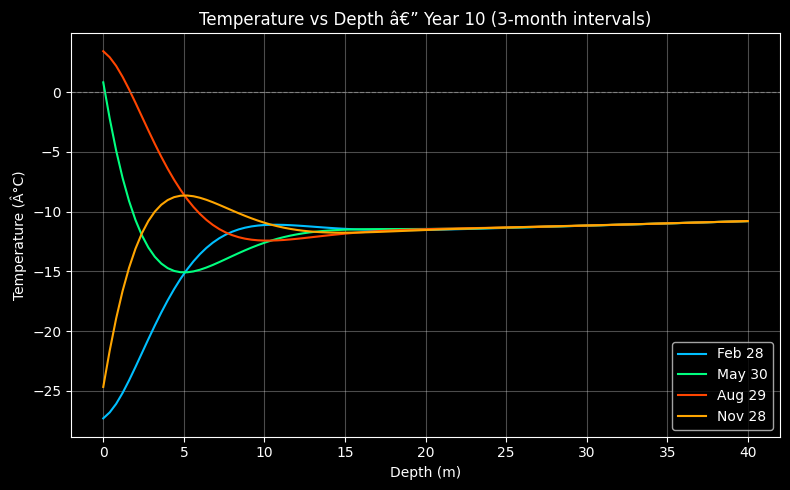

In [10]:
# 3. 

# Used Claude AI for finding these dates

quarter_days = [59, 150, 241, 332]
labels = ['Feb 28', 'May 30', 'Aug 29', 'Nov 28']
colors = ['#00bfff', '#00ff7f', '#ff4500', '#ffa500']

plt.figure(figsize=(8, 5))
for d, lbl, c in zip(quarter_days, labels, colors):
    plt.plot(x, profiles[d], label=lbl, color=c)
plt.xlabel('Depth (m)')
plt.ylabel('Temperature (Â°C)')
plt.title('Temperature vs Depth â€” Year 10 (3-month intervals)')
plt.axhline(0, color='gray', ls='--', lw=0.8)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4. Analysis


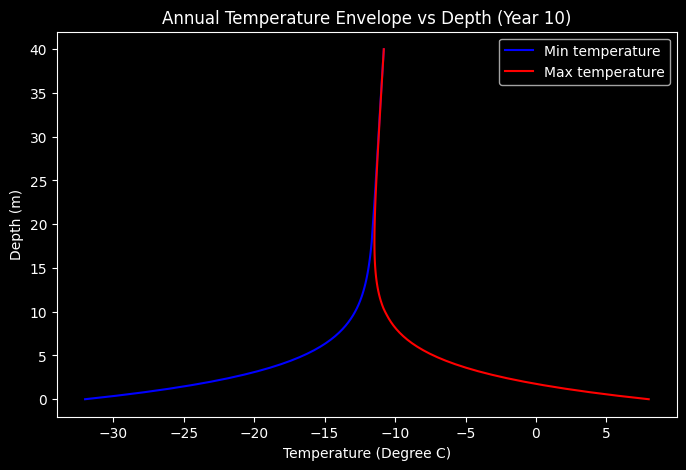

In [11]:
# 5. 

T_max = np.max(profiles, axis=0)
T_min = np.min(profiles, axis=0)

plt.figure(figsize=(8, 5))
plt.plot(T_min, x, 'b-', label='Min temperature')
plt.plot(T_max, x, 'r-', label='Max temperature')
plt.xlabel('Temperature (Degree C)')
plt.ylabel('Depth (m)')
plt.title('Annual Temperature Envelope vs Depth (Year 10)')
plt.legend()
plt.show()

6. 
**Analsysis**: I think this is the intersection of 0 on x axis and the graph. thats 1.96m

## Task 3: 

In [12]:
#1. 

L_str = 0.65 # m string length
c = 254.8 # speed m/s
Amp = 0.025  # m amplitude
d = 0.5 # m pluck position
sigma = 0.3 # width pluck

Ns = 51 #  grid points
dt_w = 1e-5 # time step
t_end = 5.0 # total time seconds
framerate = 10000  # sample rate Hz

hs = L_str / (Ns - 1)
xs = np.linspace(0, L_str, Ns)

# Number of time steps between frames
# Note that I had to use the int to make these whole numbers here, otherwise they cause errors 
# Down the code

steps_per_frame = int(round(1.0 / (framerate * dt_w)))  # = 10
total_steps = int(round(t_end / dt_w))
n_frames = int(t_end * framerate)   # 50000

rs = (c * dt_w / hs)**2


g = Amp * xs * (L_str - xs) / L_str**2 * np.exp(-(xs - d)**2 / (2 * sigma**2)) # Initial shape g(x)

u_prev = g.copy() 
u_curr = g.copy() 

# Store 
waveforms = np.zeros((n_frames, Ns))
waveforms[0] = u_curr.copy()

frame_idx = 1
for n in range(1, total_steps):
    u_next = np.zeros(Ns)
    # Update interior points
    u_next[1:-1] = (2*u_curr[1:-1] - u_prev[1:-1]
                    + rs * (u_curr[0:-2] - 2*u_curr[1:-1] + u_curr[2:]))
    # Boundary conditions: clamped ends
    u_next[0]  = 0.0
    u_next[-1] = 0.0

    u_prev = u_curr.copy()
    u_curr = u_next.copy()

    # Record at the sampling rate
    if (n % steps_per_frame) == 0 and frame_idx < n_frames:
        waveforms[frame_idx] = u_curr.copy()
        frame_idx += 1



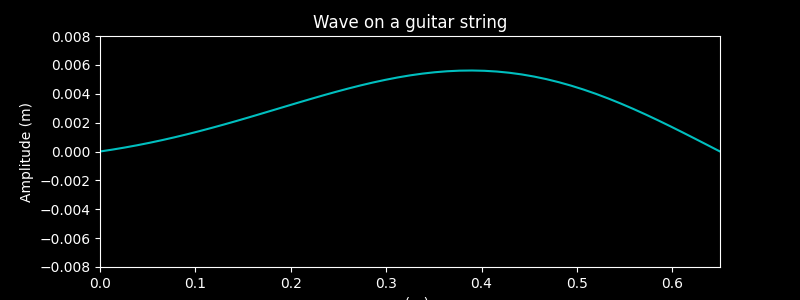

In [13]:
# 2. 

%matplotlib widget
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots(figsize=(8, 3))
line, = ax.plot(xs, waveforms[0], 'c-')
ax.set_xlim(0, L_str)
ax.set_ylim(-0.008, 0.008)
ax.set_xlabel('x (m)')
ax.set_ylabel('Amplitude (m)')
ax.set_title('Wave on a guitar string')


frame_skip = 50
def update(frame):
    idx = frame * frame_skip
    if idx < len(waveforms):
        line.set_ydata(waveforms[idx])
    return (line,)

ani = FuncAnimation(fig, update, frames=n_frames // frame_skip,
                    interval=50, blit=True)
plt.show()

In [14]:
# 3. 
from IPython.display import Audio


In [15]:
# 4. 
# I literally just copy pasted this from the Guide

freq = 196.0 # frequency of G note
framerate = 10000
t = np.linspace(0,5,framerate*5)
data = np.sin(2*np.pi*freq*t)
Audio(data,rate=framerate)

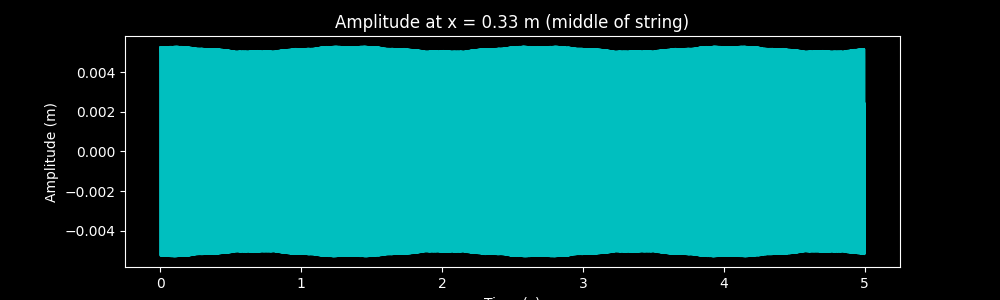

In [16]:
# 5. 

mid_idx = Ns // 2
mid_signal = waveforms[:, mid_idx]
t_plot = np.linspace(0, t_end, n_frames)

plt.figure(figsize=(10, 3))
plt.plot(t_plot, mid_signal, 'c-')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (m)')
plt.title(f'Amplitude at x = {xs[mid_idx]:.2f} m (middle of string)')
plt.show()

### 6. Play the String Waveform

In [17]:
Audio(mid_signal, rate=10000)

### 7. Analysis

One is a higher pitch(Ie, it has a higher frequnecy) than the other. 

## Task 4: Wrap Up

### 1. 
I found the Task Two a little challenging to code, I was a little lost here and there. Especially with converting the using the update formula and Interpreting the heatmap plots. 
I looked up online and apparently there is a colour map that shows the Heatmap in a more thermal read-yellow-black colors which was more easier to read, next time we could be told to use that :)

### 2. Other Comments
All ok. 